# LAB-D4-01 Instructor Solution: Accuracy Is Not Enough

**Purpose:** Choose metrics and operating thresholds from asymmetric error consequences, then expose how a high aggregate score can hide complete rare-class failure.

**Objectives:** `OBJ-D4-01`  
**Estimated duration:** 40 minutes live; completed CPU path under 30 seconds  
**Prerequisites:** [LESSON-D4-01](../../day-4/student-guide/day-4-student-guide.md#lesson-d4-01---evaluation-begins-with-consequences), [ACT-D4-01](../../day-4/challenges/day-4-challenges.md#act-d4-01---cost-council), `OBJ-D2-02`, and Day 3 split validity  
**Environment:** CPU; NumPy, matplotlib, scikit-learn; generated local data; no network or files

Workflow: **Name consequences -> Predict -> Compare baselines -> Implement metrics -> Sweep threshold -> Inspect synchronized evidence -> Choose -> Explain -> Extend**. Fraud is class `1`. The cost tables are teaching scenarios, not complete stakeholder-impact models.

In [1]:
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, confusion_matrix, precision_recall_curve,
    precision_recall_fscore_support, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 4101
MODEL_SEED = 4102
DEFAULT_THRESHOLD = 0.50
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.2})
print(f"Python {platform.python_version()} | NumPy {np.__version__} | scikit-learn {sklearn.__version__}")
print("Required path: CPU, local generated data, no network. Runtime target: under 30 seconds.")

Python 3.11.8 | NumPy 2.4.6 | scikit-learn 1.9.0
Required path: CPU, local generated data, no network. Runtime target: under 30 seconds.


## Recap: Metrics Serve a Decision

Accuracy asks how often a class decision matches. Precision asks what fraction of predicted fraud is fraud. Recall asks what fraction of fraud is found. F1 balances precision and recall, but it does not encode a scenario's actual costs. AUC summarizes ranking over many thresholds; it does not select the operating threshold.

In [2]:
started = time.perf_counter()
X, y = make_classification(
    n_samples=6000, n_features=10, n_informative=5, n_redundant=2,
    weights=[0.96, 0.04], class_sep=1.20, flip_y=0.01, random_state=SEED,
)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED,
)
assert 0.95 <= np.mean(y_val == 0) <= 0.97
print(f"Train/validation: {X_train.shape}/{X_val.shape}; validation fraud rate: {y_val.mean():.3f}")

Train/validation: (4200, 10)/(1800, 10); validation fraud rate: 0.046


## Predict Before Evidence

Commit before calculating anything: predict majority-baseline accuracy and fraud recall, name the costlier error in each scenario, choose a metric set, and predict how lowering the threshold changes false negatives and false positives.

In [3]:
metric_predictions = {
    "majority_accuracy_band": "About 0.95-0.97 because the negative class dominates.",
    "majority_fraud_recall": "Zero because no positive is predicted.",
    "scenario_one_costlier_error": "False negatives dominate the miss-heavy scenario.",
    "scenario_two_costlier_error": "False positives become relatively more important.",
    "metric_set_and_why": "Confusion counts, precision, recall, F1, and scenario cost expose both consequences.",
    "lower_threshold_effect": "Recall and false positives should both increase.",
}
assert all(value.strip() for value in metric_predictions.values()), (
    "Prediction gate: complete every field before revealing baseline metrics."
)

## Focused TODO: One Metric Row

Implement `metric_row`. Use confusion-matrix orientation `[[TN, FP], [FN, TP]]`, set `labels=[0,1]`, and pass `zero_division=0` so a no-positive-prediction baseline is informative rather than noisy.

In [4]:
def metric_row(y_true, predictions):
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, predictions, average="binary", zero_division=0
    )
    return {
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "accuracy": float(np.mean(np.asarray(y_true) == np.asarray(predictions))),
        "precision": float(precision), "recall": float(recall), "f1": float(f1),
    }

In [5]:
majority_predictions = np.zeros_like(y_val)
majority_metrics = metric_row(y_val, majority_predictions)
print("Majority baseline:", majority_metrics)
assert 0.95 <= majority_metrics["accuracy"] <= 0.97
assert majority_metrics["recall"] == 0.0 and majority_metrics["f1"] == 0.0

Majority baseline: {'tn': 1717, 'fp': 0, 'fn': 83, 'tp': 0, 'accuracy': 0.9538888888888889, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


## Observe the Accuracy-Only Failure

An accuracy-only selector may approve the majority baseline. State why that rule fails before fitting a probability model. Repair the *evaluation rule*: do not assume changing the classifier is always the first action.

In [6]:
accuracy_only_diagnosis = {
    "why_it_fails": "The majority decision hides complete failure on the rare positive class.",
    "replacement_evidence": "Report oriented confusion counts, recall, precision, F1, and consequence-weighted cost.",
}
assert all(value.strip() for value in accuracy_only_diagnosis.values())

In [7]:
probability_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=MODEL_SEED)),
])
probability_model.fit(X_train, y_train)
fraud_probability = probability_model.predict_proba(X_val)[:, 1]
default_predictions = (fraud_probability >= DEFAULT_THRESHOLD).astype(int)
default_metrics = metric_row(y_val, default_predictions)
default_metrics["roc_auc"] = float(roc_auc_score(y_val, fraud_probability))
default_metrics["average_precision"] = float(average_precision_score(y_val, fraud_probability))
print("Probability model at threshold 0.50:", default_metrics)
assert 0.55 <= default_metrics["recall"] <= 0.85

Probability model at threshold 0.50: {'tn': 1712, 'fp': 5, 'fn': 28, 'tp': 55, 'accuracy': 0.9816666666666667, 'precision': 0.9166666666666666, 'recall': 0.6626506024096386, 'f1': 0.7692307692307693, 'roc_auc': 0.8741219976001853, 'average_precision': 0.7218386563389984}


## Predict the Threshold Sweep

Two scenarios use the same model scores:

- `miss_dominant`: false negative cost `20`, false positive cost `1`.
- `block_dominant`: false negative cost `5`, false positive cost `4`.

Predict which scenario selects the lower threshold. The synthetic costs simplify delayed and uneven real consequences.

In [8]:
threshold_prediction = {
    "lower_threshold_scenario": "miss_dominant",
    "reason": "Lowering the threshold can recover costly false negatives at the price of more reviews.",
    "what_model_output_stays_fixed": "The fitted model and score ordering remain fixed.",
}
assert all(value.strip() for value in threshold_prediction.values())

COST_SCENARIOS = {
    "miss_dominant": {"false_negative": 20.0, "false_positive": 1.0},
    "block_dominant": {"false_negative": 5.0, "false_positive": 4.0},
}
thresholds = np.unique(np.r_[np.linspace(0.02, 0.98, 97), DEFAULT_THRESHOLD])
assert DEFAULT_THRESHOLD in thresholds

## Focused TODO: Synchronized Sweep

For every threshold, call `metric_row` and add each scenario cost: `FN * false_negative + FP * false_positive`. Keep all rows aligned so one selected threshold drives the table and plots.

In [9]:
def threshold_sweep(y_true, probabilities, thresholds, cost_scenarios):
    rows = []
    for threshold in thresholds:
        row = {"threshold": float(threshold), **metric_row(y_true, (probabilities >= threshold).astype(int))}
        for scenario, costs in cost_scenarios.items():
            row[f"cost_{scenario}"] = float(
                costs["false_negative"] * row["fn"] + costs["false_positive"] * row["fp"]
            )
        rows.append(row)
    return rows

sweep = threshold_sweep(y_val, fraud_probability, thresholds, COST_SCENARIOS)
assert len(sweep) == len(thresholds)
assert any(np.isclose(row["threshold"], DEFAULT_THRESHOLD) for row in sweep)

In [10]:
optimal_rows = {
    scenario: min(sweep, key=lambda row: row[f"cost_{scenario}"])
    for scenario in COST_SCENARIOS
}
for scenario, row in optimal_rows.items():
    print(scenario, {key: round(value, 4) if isinstance(value, float) else value for key, value in row.items()})
assert optimal_rows["miss_dominant"]["threshold"] != optimal_rows["block_dominant"]["threshold"]

miss_dominant {'threshold': 0.19, 'tn': 1694, 'fp': 23, 'fn': 22, 'tp': 61, 'accuracy': 0.975, 'precision': 0.7262, 'recall': 0.7349, 'f1': 0.7305, 'cost_miss_dominant': 463.0, 'cost_block_dominant': 202.0}
block_dominant {'threshold': 0.43, 'tn': 1712, 'fp': 5, 'fn': 27, 'tp': 56, 'accuracy': 0.9822, 'precision': 0.918, 'recall': 0.6747, 'f1': 0.7778, 'cost_miss_dominant': 545.0, 'cost_block_dominant': 155.0}


## Inspect: One Threshold, Multiple Consequences

Choose one scenario below. The histogram, confusion matrix, metric traces, and cost trace use the same selected row. Observe what moves with the threshold and what remains a property of the fixed probability model.

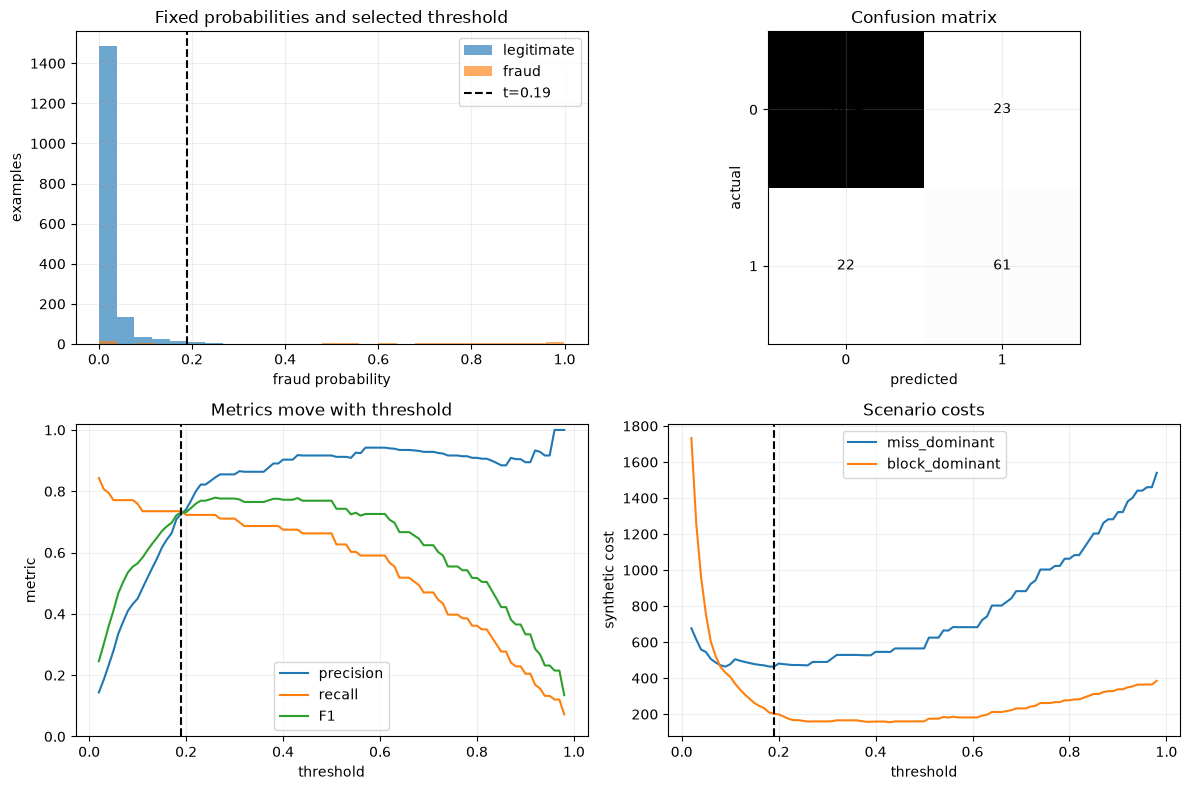

In [11]:
SELECTED_SCENARIO = "miss_dominant"
selected = optimal_rows[SELECTED_SCENARIO]
selected_threshold = selected["threshold"]
selected_predictions = (fraud_probability >= selected_threshold).astype(int)
selected_confusion = confusion_matrix(y_val, selected_predictions, labels=[0, 1])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(fraud_probability[y_val == 0], bins=25, alpha=0.65, label="legitimate")
axes[0, 0].hist(fraud_probability[y_val == 1], bins=25, alpha=0.65, label="fraud")
axes[0, 0].axvline(selected_threshold, color="black", linestyle="--", label=f"t={selected_threshold:.2f}")
axes[0, 0].set(title="Fixed probabilities and selected threshold", xlabel="fraud probability", ylabel="examples")
axes[0, 0].legend()
image = axes[0, 1].imshow(selected_confusion, cmap="Greys")
for (row, col), value in np.ndenumerate(selected_confusion): axes[0, 1].text(col, row, str(value), ha="center", va="center")
axes[0, 1].set(title="Confusion matrix", xlabel="predicted", ylabel="actual", xticks=[0,1], yticks=[0,1])
axes[1, 0].plot(thresholds, [row["precision"] for row in sweep], label="precision")
axes[1, 0].plot(thresholds, [row["recall"] for row in sweep], label="recall")
axes[1, 0].plot(thresholds, [row["f1"] for row in sweep], label="F1")
axes[1, 0].axvline(selected_threshold, color="black", linestyle="--")
axes[1, 0].set(title="Metrics move with threshold", xlabel="threshold", ylabel="metric", ylim=(0,1.02)); axes[1,0].legend()
for scenario in COST_SCENARIOS: axes[1, 1].plot(thresholds, [row[f"cost_{scenario}"] for row in sweep], label=scenario)
axes[1, 1].axvline(selected_threshold, color="black", linestyle="--")
axes[1, 1].set(title="Scenario costs", xlabel="threshold", ylabel="synthetic cost"); axes[1,1].legend()
plt.tight_layout(); plt.show()

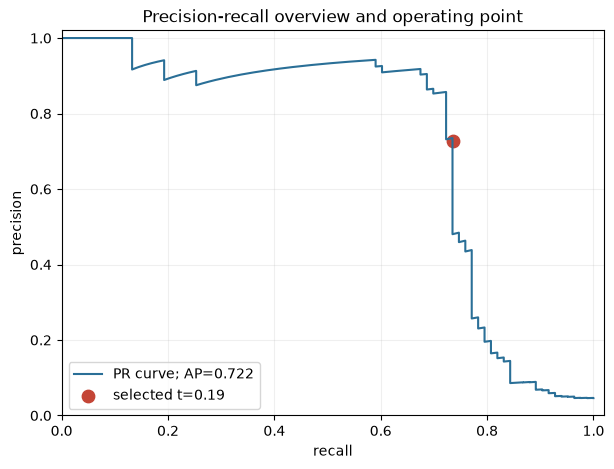

ROC AUC overview: 0.874; it ranks scores but does not choose the threshold.


In [12]:
pr_precision, pr_recall, _ = precision_recall_curve(y_val, fraud_probability)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(pr_recall, pr_precision, color="#2a6f97", label=f"PR curve; AP={default_metrics['average_precision']:.3f}")
ax.scatter(selected["recall"], selected["precision"], color="#c44536", s=80, label=f"selected t={selected_threshold:.2f}")
ax.set(title="Precision-recall overview and operating point", xlabel="recall", ylabel="precision", xlim=(0,1.02), ylim=(0,1.02)); ax.legend()
plt.show()
print(f"ROC AUC overview: {default_metrics['roc_auc']:.3f}; it ranks scores but does not choose the threshold.")

## Interpret and Defend

Cite confusion counts and consequence assumptions. A defensible answer may choose a different threshold from the cost minimum if it identifies an omitted constraint.

In [13]:
threshold_decision = {
    "scenario": "miss_dominant",
    "chosen_threshold": f"{selected_threshold:.2f}",
    "confusion_evidence": f"At the selected threshold FN={selected['fn']} and FP={selected['fp']}.",
    "metric_set": "Recall, precision, oriented confusion counts, and scenario cost.",
    "cost_assumption": "Every false negative costs 20 and every false positive costs 1.",
    "what_auc_does_not_decide": "AUC summarizes score ranking, not the deployment threshold.",
    "remaining_risk": "The classroom costs may not represent delayed or heterogeneous real consequences.",
}
assert all(value.strip() for value in threshold_decision.values())

## Deliberate Failure and Recovery

The failed rule is `max accuracy => best model`. Compare it with a consequence-aware rule. Explain why the repair changes evaluation rather than changing the already fitted probability scores.

In [14]:
accuracy_only_choice = max([("majority", majority_metrics), ("probability@0.5", default_metrics)], key=lambda item: item[1]["accuracy"])[0]
consequence_aware_choice = f"probability@{optimal_rows['miss_dominant']['threshold']:.2f}"
print("Accuracy-only choice:", accuracy_only_choice)
print("Consequence-aware operating point:", consequence_aware_choice)
assert majority_metrics["recall"] == 0.0

Accuracy-only choice: probability@0.5
Consequence-aware operating point: probability@0.19


## Challenge: Change the Consequences, Not the Model

Create one additional bounded cost scenario, predict its threshold direction, recompute only the cost column, and explain the new operating point. Do not refit the classifier.

In [15]:
RUN_OPTIONAL_SCENARIO = True
optional_scenario = {"false_negative": 12.0, "false_positive": 2.0}
optional_interpretation = {
    "prediction": "The optimum should lie between the two supplied scenarios.",
    "observed_threshold": "Recorded from optional_best after execution.",
    "explanation": "The threshold follows the declared cost ratio while model scores remain fixed.",
}
if RUN_OPTIONAL_SCENARIO:
    optional_rows = threshold_sweep(y_val, fraud_probability, thresholds, {"optional": optional_scenario})
    optional_best = min(optional_rows, key=lambda row: row["cost_optional"])
    optional_interpretation["observed_threshold"] = f"{optional_best['threshold']:.2f}"
    print("Optional best row:", optional_best)
    assert all(value.strip() for value in optional_interpretation.values())

Optional best row: {'threshold': 0.26, 'tn': 1706, 'fp': 11, 'fn': 23, 'tp': 60, 'accuracy': 0.9811111111111112, 'precision': 0.8450704225352113, 'recall': 0.7228915662650602, 'f1': 0.7792207792207793, 'cost_optional': 298.0}


## Reflection, Takeaways, and Troubleshooting

1. High accuracy can coexist with zero rare-class recall.
2. Threshold movement changes class decisions, not the underlying probability ranking.
3. Precision, recall, F1, PR, and ROC/AUC answer different questions; none supplies stakeholder costs.
4. State the positive class and confusion orientation every time.

| Symptom | Likely cause | Recovery |
|---|---|---|
| Undefined metric warning | No positive predictions and unsafe defaults | Use `zero_division=0` and inspect counts |
| Costs appear reversed | FN/FP orientation swapped | Confirm `[[TN,FP],[FN,TP]]` |
| Threshold `0.5` missing | Sweep grid omitted it | Include it explicitly |
| Runtime exceeds 30 seconds | Dataset/model budget changed | Restore 6,000 examples and one logistic fit |

In [16]:
assert majority_metrics["recall"] == 0.0
assert 0.55 <= default_metrics["recall"] <= 0.85
assert optimal_rows["miss_dominant"]["threshold"] != optimal_rows["block_dominant"]["threshold"]
assert all(value.strip() for value in threshold_decision.values())
print(f"LAB-D4-01 checkpoint passed in {time.perf_counter() - started:.2f}s: baseline exposed, thresholds synchronized, and a consequence-aware decision recorded.")

LAB-D4-01 checkpoint passed in 0.64s: baseline exposed, thresholds synchronized, and a consequence-aware decision recorded.


## Continue

Use the Day 4 guide debrief: [LAB-D4-01 Debrief - What Changed, and What Did Not?](../../day-4/student-guide/day-4-student-guide.md#lab-d4-01-debrief---what-changed-and-what-did-not).

---

## Instructor Debrief: What, Why, and Concept

**Correct implementation.** `metric_row` fixes the label order as `[0, 1]`, unpacks `[[TN, FP], [FN, TP]]`, and computes precision, recall, and F1 with `zero_division=0`. `threshold_sweep` applies one threshold at a time to the unchanged probability scores, then computes every metric and every declared consequence cost from the same confusion counts.

**Why it is correct.** The majority classifier obtains about **0.9539 accuracy** because the negative class is about 95.4% of validation examples, yet its minority recall and F1 are both **0**. Accuracy answers how often the classifier is right under the observed class mix; it does not encode the asymmetric consequence of a missed positive. The fitted probability model at threshold `0.50` recovers about **0.6627 recall**, **0.9167 precision**, and **0.7692 F1**. Under the miss-dominant cost, the minimum-cost operating point is `0.19`; under the block-dominant cost it is `0.43`. The optional intermediate cost selects about `0.26`.

**Concept.** The deliberate accuracy-only rule selects `probability@0.5`, not the majority baseline, on this seeded data. That choice is still wrong for the miss-dominant decision because `0.19` has lower declared cost. Keep this distinction explicit: the lesson is not that accuracy must always select the majority model; it is that an accuracy-only model/threshold rule can select a non-cost-optimal operating point.


## Expected Evidence and Plot Reading

- Majority baseline: accuracy in `0.95-0.97`, `TN=1717`, `FP=0`, `FN=83`, `TP=0`, minority recall `0`, F1 `0`.
- Probability model at `0.50`: recall in the calibrated `0.55-0.85` band; this run is about `0.6627`.
- Cost optima: miss-dominant `0.19`, block-dominant `0.43`, optional intermediate `0.26`. Small version-level numeric changes are acceptable only if the confusion/cost arithmetic is internally consistent and the scenarios still lead to different decisions.
- Threshold dashboard: all confusion counts, rates, and costs at one x-position must come from the same threshold. Lowering the threshold normally raises both TP and FP; it does not refit or reorder the probability scores.
- Precision-recall plot: the selected operating point belongs to the declared consequence model. Average precision and ROC AUC summarize ranking behavior across thresholds; neither chooses a deployment threshold or supplies a cost model.

Discussion trigger: "If AUC is unchanged when the threshold moves, what decision-relevant evidence did change?" Expected answer: the confusion counts, precision/recall trade-off, and consequence cost changed while score ranking stayed fixed.


## Hint Ladder, Misconceptions, and Alternatives

1. Ask which class a majority classifier never predicts.
2. Ask participants to mark true-label rows and predicted-label columns before naming TN/FP/FN/TP.
3. Ask which error receives the larger multiplier in each scenario.
4. Point to the same probability vector and ask what the threshold changes.
5. Only then suggest comparing `FN * C_FN + FP * C_FP` for each row.

Common wrong answers:

- "95% accuracy means the baseline is useful." It misses every positive example.
- "Lower threshold improves the model." It changes the operating point, not the fitted ranking model, and can increase false positives.
- "AUC says to use `0.19`." AUC contains no deployment consequence or threshold-selection rule.
- "F1 is the cost function." F1 weights precision and recall through its own definition; it does not represent the stated monetary or operational costs.
- "The optimal threshold is permanent." It is conditional on prevalence, calibration, data drift, and the declared cost assumptions.

Acceptable alternatives include a constrained-recall rule, a maximum false-positive-rate rule, or expected utility with a different documented cost matrix. They are valid only when the decision rule is declared before selecting the threshold and evaluated on held-out evidence.


## Instructor Operations and Recovery

Run from top to bottom on CPU. The required path uses generated in-notebook data, fixed seeds, no files, and no network. Expect a few seconds after kernel startup and two nonblank plots. Exact timing is host-specific.

Troubleshooting:

- If confusion values appear swapped, verify `labels=[0, 1]` and rows=true, columns=predicted.
- If metric warnings appear for the majority baseline, verify `zero_division=0` is passed to precision, recall, and F1.
- If the selected threshold is absent, verify `0.50` is explicitly unioned into the grid and do not round before cost minimization.
- If scenario decisions are identical, inspect whether each scenario uses its own FN/FP multipliers.
- If a live plot fails, preserve predictions and the cost declaration, rerun the synchronized table, and discuss from the printed optimum rows. Do not substitute an AUC-only conclusion.

Reproducibility note: fixed seeds support this local CPU result but do not turn the calibrated values into universal production thresholds. A hosted Colab CPU run remains a separate environment check.
